In [158]:
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import Dataset
from torch.utils.data.dataloader import DataLoader
from torch.utils.tensorboard import SummaryWriter

from matplotlib import pyplot as plt

In [ ]:
with open("names.txt",'r') as f: #reading a txt file 
    data=f.read()

words=data.splitlines() #converting the txt file to list

In [160]:
char=sorted(list(set(''.join(words))))
char.insert(0,'.')
stoi={ch:i for i,ch in enumerate(char)}
itos={ch:i for ch,i in enumerate(char)}

In [176]:
block_size=3

def dataset_prep(words):
    X,y=[],[]
    for w in words:
        
        context=[0]*block_size
        for ch in w +'.':
            ix=stoi[ch]
            X.append(context)
            y.append(ix)
            # print("".join(itos[i] for i in context),itos[ix])
            context=context[1:]+[ix]
    X=torch.tensor(X)
    y=torch.tensor(y)
    return X,y

import random 
random.seed(42)
random.shuffle(words)
n1=int(0.8*len(words))
n2=int(0.9*len(words))

Xtr,ytr=dataset_prep(words[:n1])
Xval,yval=dataset_prep(words[n1:n2])
Xte,yte=dataset_prep(words[n2:])
    


In [177]:
g=torch.Generator().manual_seed(226)
C=torch.randn((27,2),generator=g) #This is defining embadding 
W1=torch.randn((6,300),generator=g)
b1=torch.randn(300,generator=g)
W2=torch.randn((300,27),generator=g)
b2=torch.randn(27,generator=g)
parameters=[C,W1,b1,W2,b2]

In [178]:
for p in parameters:
    p.requires_grad=True

In [179]:
#To find a good learning rate
lre=torch.linspace(-3,0,1000)
lrs=10**lre

In [180]:
lri=[]
lossi=[]
for i in range(1000):
    #min batchs to run the loop faster with a sampled dataset
    ix=torch.randint(0,Xtr.shape[0],(32,))
    #forward pass
    emb=C[Xtr[ix]]
    h1=torch.tanh(emb.view(emb.shape[0],6) @ W1 + b1) # This wont work directly as C shape is [32,3,2] W1 is [6,100] need to change the view of emb
    logit=h1 @ W2+b2
    loss=F.cross_entropy(logit,ytr[ix])
    print(loss.item())
    #backward pass
    for p in parameters:
        p.grad=None
    loss.backward()
    lr=lrs[i]
    for p in parameters:
        p.data += -lr*p.grad

    lri.append(lr)
    lossi.append(loss.item())


34.48005676269531
26.54605484008789
26.481225967407227
24.850675582885742
29.381868362426758
31.75969123840332
27.64666175842285
30.561141967773438
23.771934509277344
29.137235641479492
34.85788345336914
25.06252098083496
34.55725860595703
33.6963005065918
27.058462142944336
29.644575119018555
27.523990631103516
30.3902587890625
27.272153854370117
27.686893463134766
27.788320541381836
24.30128288269043
33.99535369873047
29.74213981628418
33.46773147583008
32.95753479003906
22.921409606933594
27.354869842529297
29.445480346679688
29.884624481201172
33.302520751953125
30.801837921142578
28.281997680664062
29.76434326171875
29.933483123779297
31.271175384521484
34.8609619140625
29.2481746673584
27.827280044555664
26.934123992919922
30.956159591674805
27.894746780395508
30.22699546813965
27.675283432006836
25.091325759887695
27.857500076293945
22.384828567504883
27.233835220336914
28.60838508605957
19.795654296875
26.954299926757812
27.640527725219727
30.532018661499023
25.899227142333984


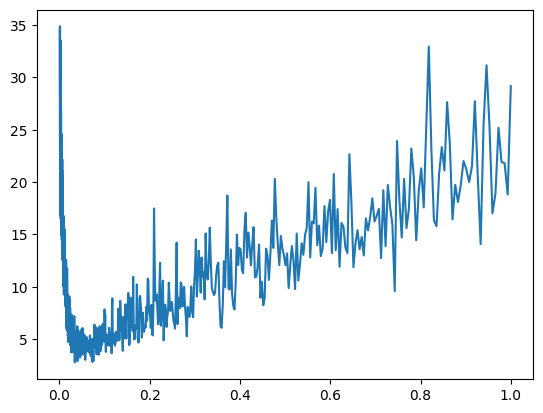

In [181]:
plt.plot(lri,lossi) #from this we get a learning rate which is around 0.1

In [182]:
#training the model with lr 0.1
for i in range(30000):
    #min batchs to run the loop faster with a sampled dataset
    ix=torch.randint(0,Xtr.shape[0],(32,))
    #forward pass
    emb=C[Xtr[ix]]
    h1=torch.tanh(emb.view(emb.shape[0],6) @ W1 + b1) # This wont work directly as C shape is [32,3,2] W1 is [6,100] need to change the view of emb
    logit=h1 @ W2+b2
    loss=F.cross_entropy(logit,ytr[ix])
    # print(loss.item())
    #backward pass
    for p in parameters:
        p.grad=None
    loss.backward()
    lr=0.1
    for p in parameters:
        p.data += -lr*p.grad

    # lri.append(lr)
    # lossi.append(loss.item())
print(loss.item())

2.8109467029571533


In [183]:
emb=C[Xval]
h=h1=torch.tanh(emb.view(emb.shape[0],6) @ W1 + b1)
logit=h1 @ W2+b2
loss_train=F.cross_entropy(logit,yval)
loss_train
#People also do learning rate decay where they train a model and for last few step they decrease the rate
# 
# train loss is 2.82 and dev loss is 2.33 which mean that the nn is not completely trian we need to scale you our parameters 
# This results is with 100 nn now change it to 300 

tensor(2.5638, grad_fn=<NllLossBackward0>)

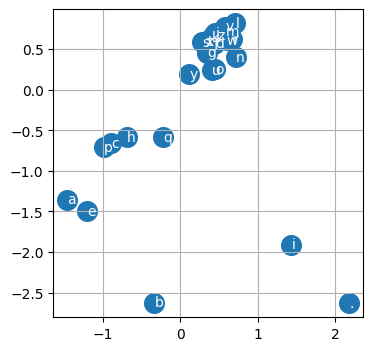

In [185]:
#visulizating the embedding
plt.figure(figsize=(4,4))
plt.scatter(C[:,0].data,C[:,1].data,s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(),C[i,1].item(),itos[i],va='center',color='white')
plt.grid('minor')

In [187]:
#sampling for the model 
g=torch.Generator().manual_seed(42)

for _ in range(20):
    out=[]
    context=[0]*block_size
    while True:
        emb=C[torch.tensor(context)]
        h=torch.tanh(emb.view(1,-1) @W1+b1)
        logit= h @ W2 +b2
        prob=F.softmax(logit,dim=1)
        ix=torch.multinomial(prob,num_samples=1,generator=g).item()
        context=context[1:]+[ix]
        out.append(ix)
        if ix==0:
            break

    print(''.join(itos[i] for i in out))


yensy.
hheliennelie.
mha.
miony.
peryahdachel.
emberlynn.
ize.
hakeles.
adha.
oyree.
tuw.
pupo.
zhn.
zhalishalled.
whin.
cacn.
cayahimorie.
arten.
hagsem.
amwei.
